# Geospatial Data

In [5]:
!pip cache purge --quiet

In [6]:
!pip install folium==0.20.0 \
             geopy==2.4.1 \
             matplotlib==3.10.5 \
             networkx==3.5 --quiet

In [7]:
import base64
import folium
import matplotlib.pyplot as plt
import mimetypes
import networkx as nx
import pandas as pd

from folium import plugins
from geopy.distance import geodesic
from IPython.display import HTML

INFO:matplotlib.font_manager:generated new fontManager


<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [8]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [9]:
lines_df = pd.read_sql(
    "SELECT * FROM london_lines",
    con = db_connection
)

In [10]:
connections_df = pd.read_sql(
    "SELECT * FROM london_connections",
    con = db_connection
)

In [11]:
stations_df = pd.read_sql(
    "SELECT * FROM london_stations",
    con = db_connection
)

In [12]:
merged_df = connections_df.merge(
    lines_df,
    on = "tube_line",
    how = "left"
)

In [13]:
# Merge for "From Station"
df1 = merged_df.merge(
    stations_df[["station", "latitude", "longitude", "zone"]],
    left_on = "from_station",
    right_on = "station",
    how = "left",
    suffixes = ("", "_from")
)

In [14]:
# Merge for "To Station"
df2 = df1.merge(
    stations_df[["station", "latitude", "longitude", "zone"]],
    left_on = "to_station",
    right_on = "station",
    how = "left",
    suffixes = ("", "_to")
)

In [15]:
# Drop redundant "Station" columns
df2 = df2.drop(columns = ["station", "station_to"])

In [16]:
# Rename for clarity
final_df = df2.rename(columns = {
    "latitude": "from_latitude",
    "longitude": "from_longitude",
    "zone": "from_zone",
    "latitude_to": "to_latitude",
    "longitude_to": "to_longitude",
    "zone_to": "to_zone"
})

In [17]:
# Add a new distance column
final_df["distance"] = final_df.apply(
    lambda row: geodesic(
        (row["from_latitude"], row["from_longitude"]),
        (row["to_latitude"], row["to_longitude"])
    ).km,
    axis = 1
)

In [18]:
with db_connection.begin() as conn:
    conn.execute(text("TRUNCATE TABLE london_tube_edges;"))

In [19]:
final_df.to_sql(
    "london_tube_edges",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

458

In [20]:
final_df.head()

,tube_line,from_station,to_station,color,from_latitude,from_longitude,from_zone,to_latitude,to_longitude,to_zone,distance
0,Circle,Shepherds Bush Market,Wood Lane,#FFD300,51.505880,-0.227400,2,51.509658,-0.224473,2,0.466856
1,District,Cannon Street,Mansion House,#00782A,51.511362,-0.090251,1,51.512092,-0.094198,1,0.285793
2,Northern,Colliers Wood,Tooting Broadway,#000000,51.418759,-0.177415,3,51.427049,-0.168685,3,1.104285
3,Northern,Woodside Park,Totteridge and Whetstone,#000000,51.617868,-0.185426,4,51.630246,-0.179354,4,1.439964
4,Piccadilly,Eastcote,Ruislip Manor,#003688,51.576551,-0.396823,5,51.573451,-0.412849,6,1.163343


In [21]:
# Create graph directly from final_df edges
graph = nx.from_pandas_edgelist(
    final_df,
    source = "from_station",
    target = "to_station",
    edge_attr = ["color", "distance", "tube_line"]
)

In [22]:
# Create position dict directly from final_df station coords
# Combine from_station and to_station coords into one dict

pos = {}

for _, row in final_df.iterrows():
    pos[row["from_station"]] = (row["from_longitude"], row["from_latitude"])
    pos[row["to_station"]] = (row["to_longitude"], row["to_latitude"])

# Edge colors for drawing
edge_colors = [data["color"] for _, _, data in graph.edges(data = True)]

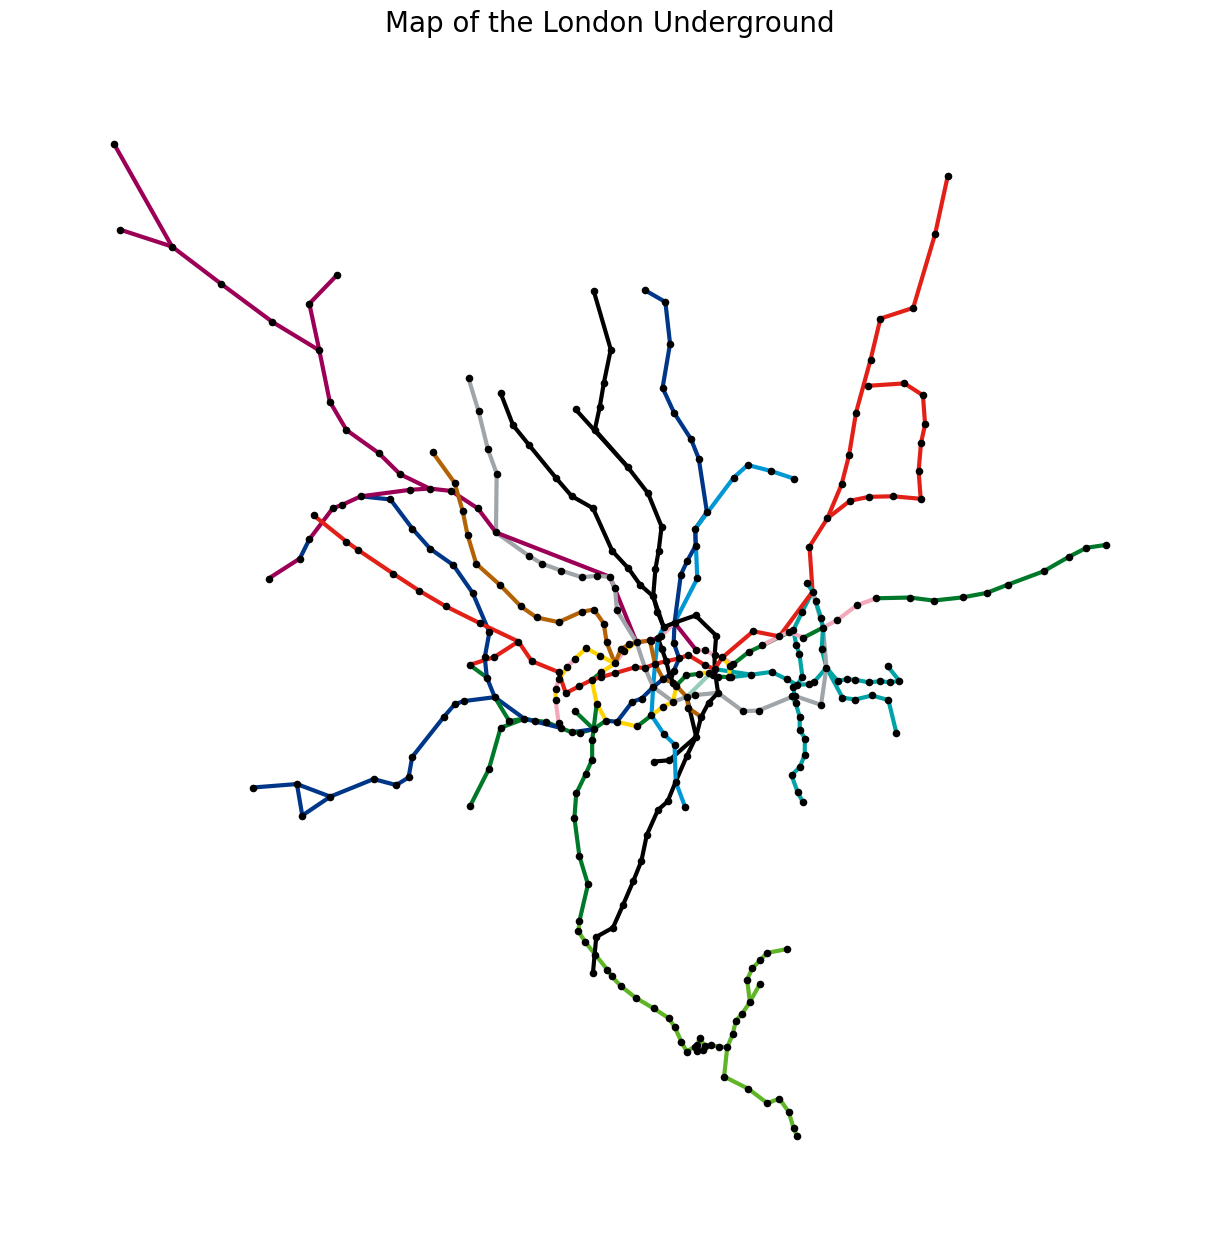

In [23]:
plt.figure(figsize = (12, 12))

nx.draw(
    graph,
    pos = pos,
    edge_color = edge_colors,
    node_size = 20,
    node_color = "black",
    width = 3
)

plt.title("Map of the London Underground", size = 20)
lu_map = "london_underground_map.png"
plt.savefig(lu_map, dpi = 300)
plt.show()


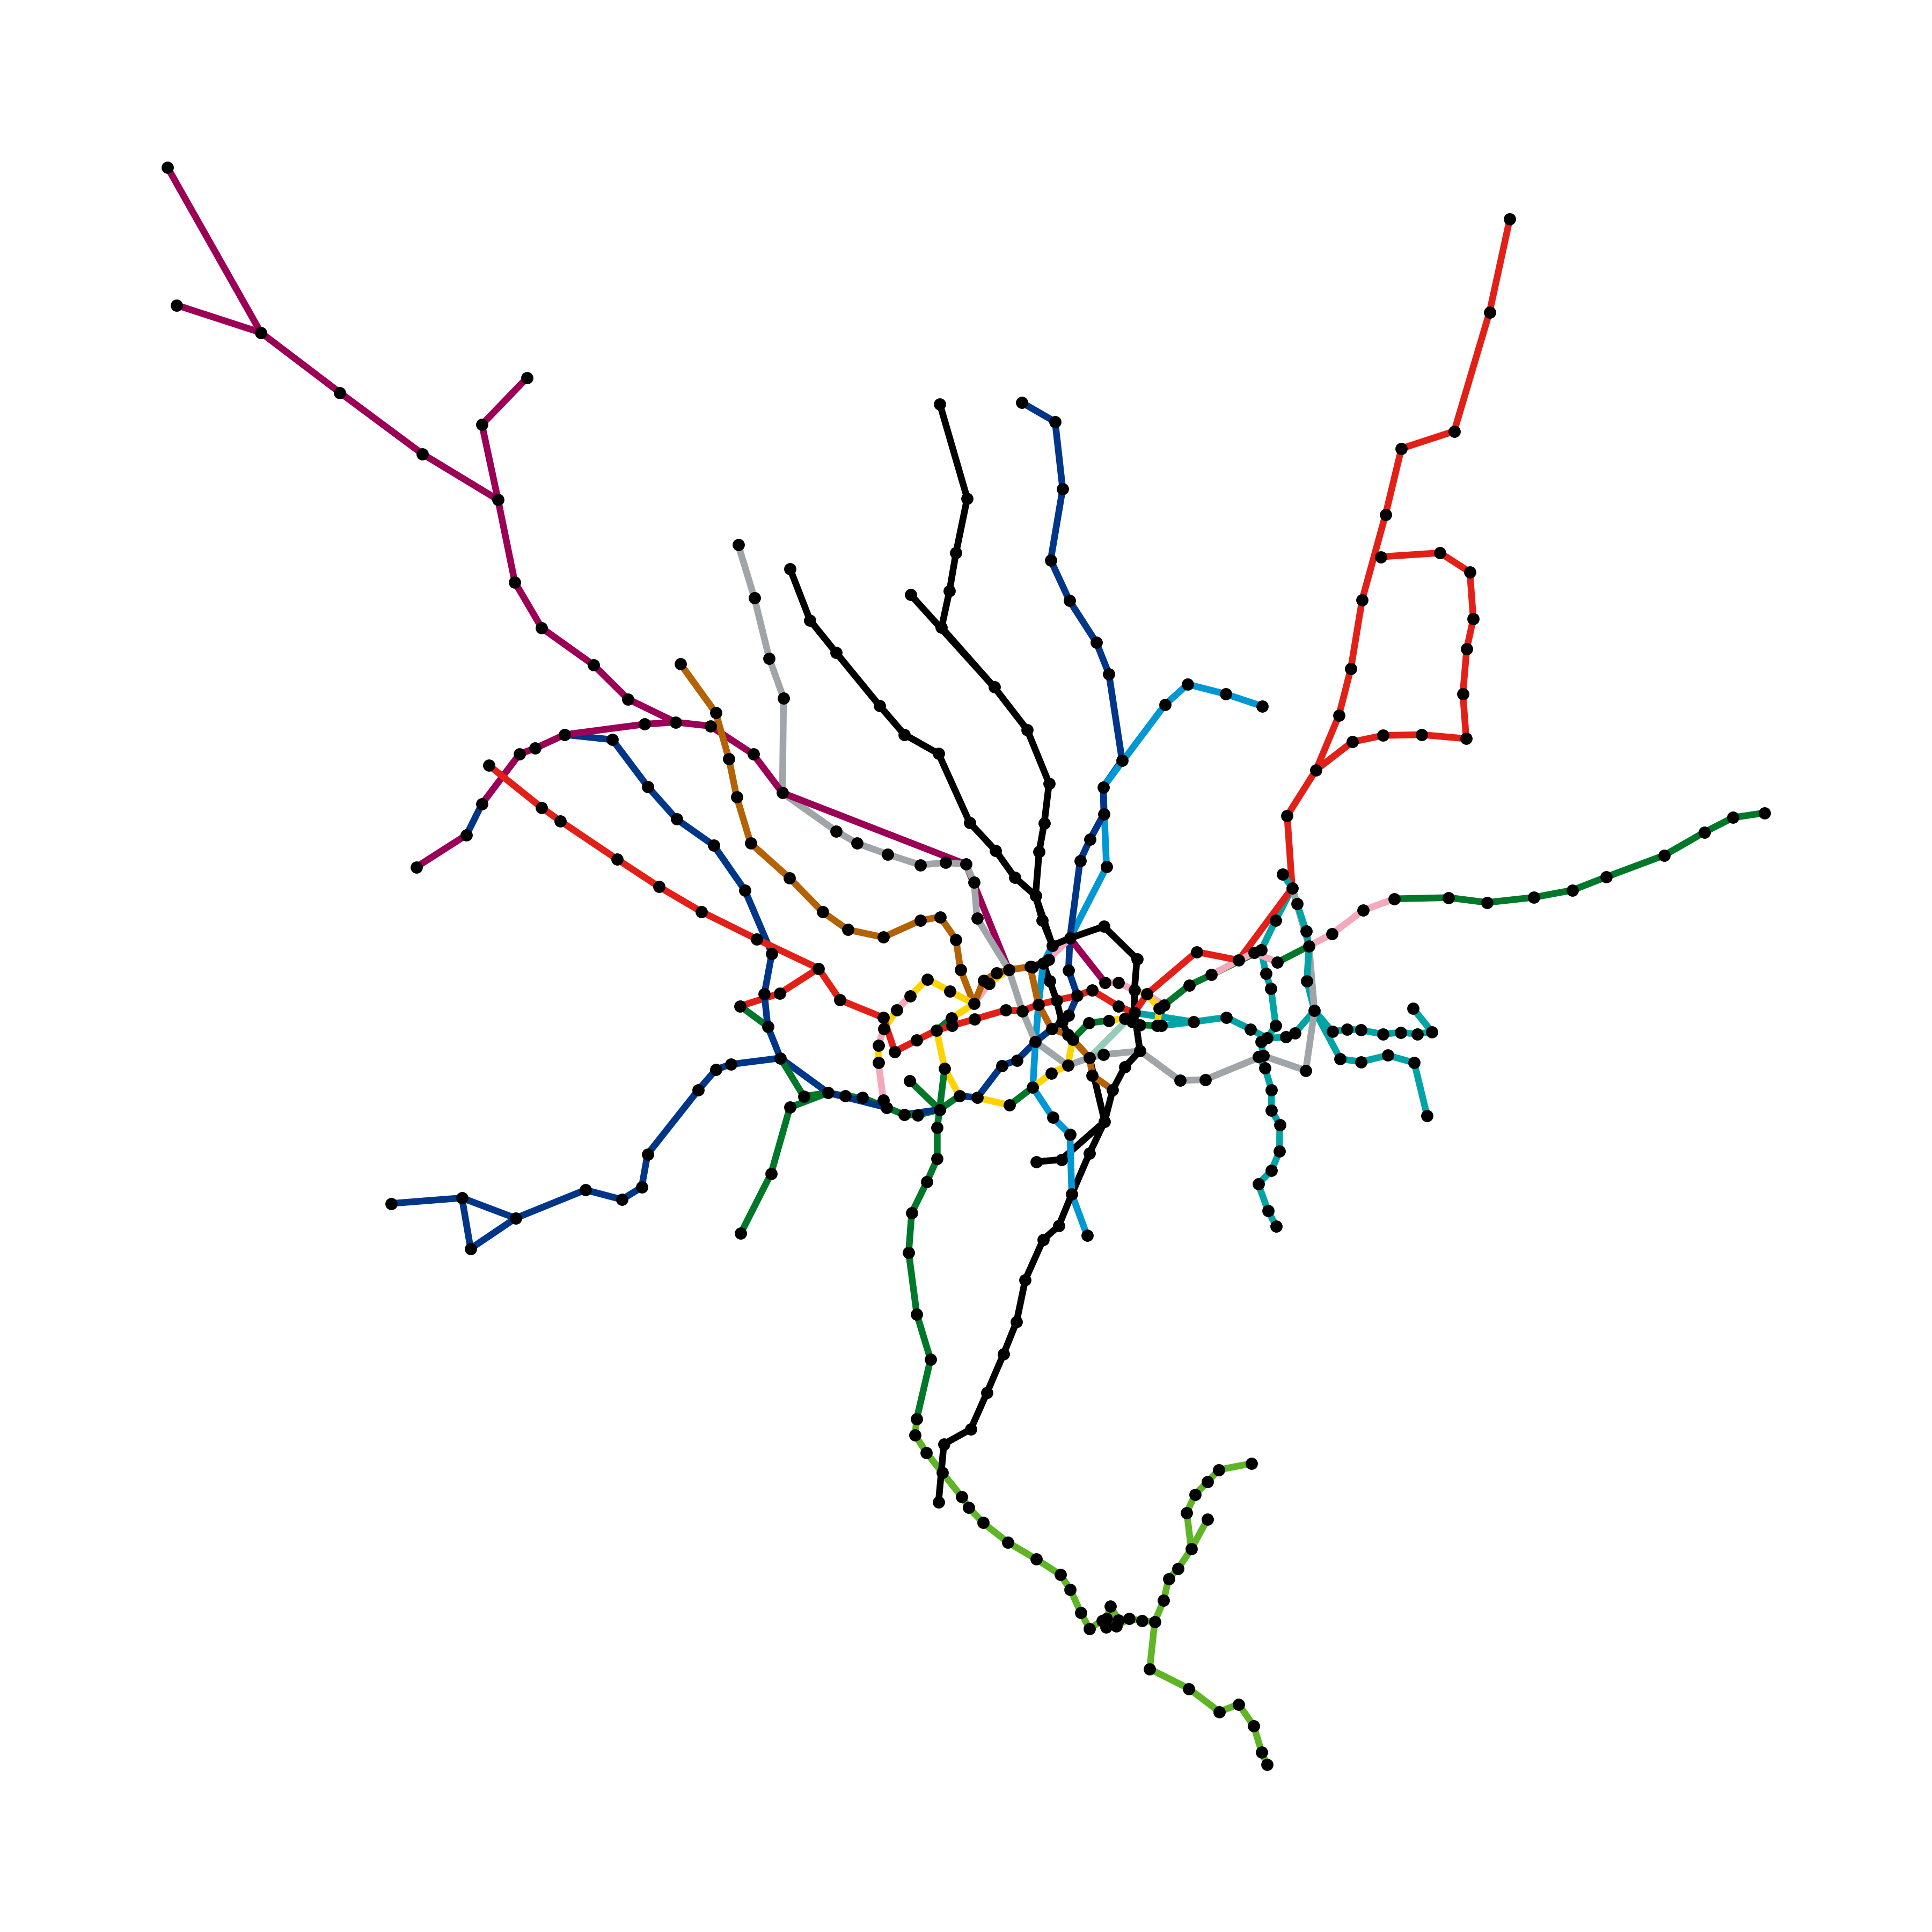

In [25]:
mime_type, _ = mimetypes.guess_type(lu_map)

with open(lu_map, "rb") as f:
    data = f.read()
b64 = base64.b64encode(data).decode()
href = f'<a download="{lu_map}" href="data:{mime_type};base64,{b64}">Download {lu_map}</a>'
HTML(href)

In [26]:
# Center the map on London
m = folium.Map(location = [51.509865, -0.118092], zoom_start = 11)

# Add tube line connections (edges)
for _, row in final_df.iterrows():
    coords = [
        (row["from_latitude"], row["from_longitude"]),
        (row["to_latitude"], row["to_longitude"])
    ]

    folium.PolyLine(
        coords,
        color = row["color"] if pd.notnull(row["color"]) else "#808080",
        weight = 5,
        opacity = 0.7
    ).add_to(m)

# Add unique station markers (nodes)
stations_seen = set()

for _, row in final_df.iterrows():
    # Add from_station
    if row["from_station"] not in stations_seen:
        folium.CircleMarker(
            location = (row["from_latitude"], row["from_longitude"]),
            radius = 4,
            color = "black",
            fill = True,
            fill_color = "white",
            fill_opacity = 0.9,
            popup = row["from_station"]
        ).add_to(m)
        stations_seen.add(row["from_station"])

    # Add to_station
    if row["to_station"] not in stations_seen:
        folium.CircleMarker(
            location = (row["to_latitude"], row["to_longitude"]),
            radius = 4,
            color = "black",
            fill = True,
            fill_color = "white",
            fill_opacity = 0.9,
            popup = row["to_station"]
        ).add_to(m)
        stations_seen.add(row["to_station"])

# Save the map
lu_map_html = "lu_map.html"
m.save(lu_map_html)

In [27]:
mime_type, _ = mimetypes.guess_type(lu_map_html)

with open(lu_map_html, "rb") as f:
    data = f.read()
b64 = base64.b64encode(data).decode()
href = f'<a download="{lu_map_html}" href="data:{mime_type};base64,{b64}">Download {lu_map_html}</a>'
HTML(href)

In [28]:
# Create an empty graph

G = nx.Graph()

# Add edges directly using the DataFrame values

for _, row in final_df.iterrows():
    G.add_edge(
        row["from_station"],
        row["to_station"],
        weight = row["distance"]
    )

In [29]:
# Use Dijkstra's algorithm to find the shortest path between any two stations.
# This returns the list of station names representing the shortest route.

source = "Wimbledon"
target = "South Wimbledon"

shortest_path = nx.shortest_path(
    G,
    source = source,
    target = target,
    weight = "weight"
)

print("Shortest Path:", shortest_path)

Shortest Path: ['Wimbledon', 'Wimbledon Park', 'Southfields', 'East Putney', 'Putney Bridge', 'Parsons Green', 'Fulham Broadway', 'West Brompton', 'Earls Court', 'Gloucester Road', 'South Kensington', 'Sloane Square', 'Victoria', 'Pimlico', 'Vauxhall', 'Stockwell', 'Clapham North', 'Clapham Common', 'Clapham South', 'Balham', 'Tooting Bec', 'Tooting Broadway', 'Colliers Wood', 'South Wimbledon']


In [30]:
# Center the map roughly on London
m = folium.Map(location = [51.509865, -0.118092], zoom_start = 13)

# Build station coordinates lookup from final_df
station_coords = {}
for _, row in final_df.iterrows():
    station_coords[row["from_station"]] = (row["from_latitude"], row["from_longitude"])
    station_coords[row["to_station"]] = (row["to_latitude"], row["to_longitude"])

# Build tube line color lookup from final_df
line_colors = final_df[["tube_line", "color"]].drop_duplicates().set_index("tube_line")["color"].to_dict()

# Plot each segment of the shortest path
for i in range(len(shortest_path) - 1):
    from_station = shortest_path[i]
    to_station = shortest_path[i + 1]

    from_coords = station_coords[from_station]
    to_coords = station_coords[to_station]

    # Look up the tube line for this segment
    line_match = final_df[
        ((final_df["from_station"] == from_station) & (final_df["to_station"] == to_station)) |
        ((final_df["from_station"] == to_station) & (final_df["to_station"] == from_station))
    ]

    if not line_match.empty:
        tube_line = line_match.iloc[0]["tube_line"]
        line_color = line_colors.get(tube_line, "blue")
    else:
        line_color = "blue"  # fallback color

    # Draw the segment on the map
    folium.PolyLine(
        [from_coords, to_coords],
        color = line_color,
        weight = 5,
        opacity = 0.8
    ).add_to(m)

# Add markers for each station on the path
for i, station in enumerate(shortest_path):
    coords = station_coords[station]

    if station == source:
        folium.Marker(
            location = coords,
            popup = f"Start: {station}",
            icon = folium.Icon(color = "green")
        ).add_to(m)
    elif station == target:
        folium.Marker(
            location = coords,
            popup = f"End: {station}",
            icon = folium.Icon(color = "red")
        ).add_to(m)
    else:
        folium.Marker(
            location = coords,
            popup = station,
            icon = folium.Icon(icon = "train", prefix = "fa", color = "gray")
        ).add_to(m)

# Save the map
shortest_route_map_html = "shortest_route_map.html"
m.save(shortest_route_map_html)

In [31]:
mime_type, _ = mimetypes.guess_type(shortest_route_map_html)

with open(shortest_route_map_html, "rb") as f:
    data = f.read()
b64 = base64.b64encode(data).decode()
href = f'<a download="{shortest_route_map_html}" href="data:{mime_type};base64,{b64}">Download {shortest_route_map_html}</a>'
HTML(href)